## Environment Setup & Quantification Function

In [1]:
# --- Import Core Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Configure high-resolution plot settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8


def calculate_recovery_time(t, eeg, pulse_time=1.0, k_sigma=2.5, sustained_ms=50.0, fs=5000):
    """
    Quantifies the recovery time of a perturbed EEG signal using the Hilbert transform envelope.

    Parameters:
    -----------
    t : np.ndarray
        Time array in seconds.
    eeg : np.ndarray
        Simulated EEG signal time-series.
    pulse_time : float
        Timestamp of the TMS pulse injection in seconds (default: 1.0s).
    k_sigma : float
        Standard deviation multiplier for thresholding.
    sustained_ms : float
        Minimum continuous window (ms) required inside threshold for true recovery.
    fs : int
        Sampling rate in Hz.

    Returns:
    --------
    recovery_time : float
        Time elapsed in seconds from pulse_time to baseline return (np.nan if no recovery).
    envelope : np.ndarray
        Instantaneous amplitude envelope extracted via Hilbert transform.
    threshold : float
        Calculated baseline recovery threshold.
    t_return : float
        Absolute timestamp of recovery.
    """
    # Step 1: Compute instantaneous envelope via Hilbert transform
    analytic_signal = hilbert(eeg)
    envelope = np.abs(analytic_signal)

    # Step 2: Calculate pre-stimulus baseline envelope statistics (0.2s to pulse_time)
    baseline_mask = (t >= 0.2) & (t < pulse_time)
    baseline_envelope = envelope[baseline_mask]

    mu_base = np.mean(baseline_envelope)
    sigma_base = np.std(baseline_envelope)
    threshold = mu_base + (k_sigma * sigma_base)

    # Step 3: Analyze post-pulse envelope trajectory (t >= pulse_time)
    post_pulse_mask = t >= pulse_time
    t_post = t[post_pulse_mask]
    envelope_post = envelope[post_pulse_mask]

    # Identify indices below recovery threshold
    below_threshold_mask = envelope_post <= threshold
    sustained_samples = int((sustained_ms / 1000.0) * fs)

    t_return = np.nan
    recovery_time = np.nan

    # Step 4: Sliding window evaluation for sustained baseline re-entry
    for i in range(len(below_threshold_mask) - sustained_samples):
        if np.all(below_threshold_mask[i : i + sustained_samples]):
            t_return = t_post[i]
            recovery_time = t_return - pulse_time
            break

    return recovery_time, envelope, threshold, t_return

## 10D Wendling Neural Mass Model Implementation

In [5]:
class WendlingModelQuantification:
    """
    10D Wendling Neural Mass Model using original Wendling 2002 parameters
    with integrated single-pulse TMS perturbation support.
    """
    def __init__(self, B=15.0, G=10.0, dt=0.0002, T=2.2, random_seed=42):
        self.dt = dt
        self.T = T
        self.N = int(T / dt)
        self.time = np.linspace(0, T, self.N)

        if random_seed is not None:
            np.random.seed(random_seed)

        # Physiological Gains (mV)
        self.A = 5.0      # Excitatory gain
        self.B = B        # Slow inhibitory gain (Dynamic per regime)
        self.G = G        # Fast inhibitory gain (Dynamic per regime)

        # Synaptic pool time constants (s^-1)
        self.a = 100.0    # Excitatory
        self.b = 50.0     # Slow inhibitory
        self.g = 350.0    # Fast inhibitory

        # Sigmoid Parameter Profiles
        self.e0 = 2.5
        self.v0 = 6.0
        self.r = 0.56

        # Dimensionless Connectivity Constants (Wendling 2002)
        self.C1 = 135.0
        self.C2 = 108.0
        self.C3 = 33.75
        self.C4 = 33.75
        self.C5 = 40.5
        self.C6 = 13.5
        self.C7 = 27.0

        # Afferent drive configuration
        self.p_mean = 90.0
        self.p_std = 2.0    # Calibrated noise strength

    def sigmoid(self, v):
        return (2.0 * self.e0) / (1.0 + np.exp(self.r * (self.v0 - v)))

    def simulate(self, pulse_intensity=2500.0, pulse_start=1.0, pulse_duration=0.01):
        """
        Executes Euler-Maruyama SDE solver with TMS pulse at pulse_start (t = 1.0s)
        """
        y = np.zeros((10, self.N))

        for t_idx in range(1, self.N):
            t_curr = self.time[t_idx]

            # Smooth input warmup over first 0.5s
            current_p_mean = self.p_mean if t_curr > 0.5 else self.p_mean * (t_curr / 0.5)

            # Inject transient single-pulse TMS perturbation at pulse_start
            if pulse_start <= t_curr <= (pulse_start + pulse_duration):
                current_p_mean += pulse_intensity

            y0, y1, y2, y3, y4 = y[0, t_idx-1], y[1, t_idx-1], y[2, t_idx-1], y[3, t_idx-1], y[4, t_idx-1]
            y5, y6, y7, y8, y9 = y[5, t_idx-1], y[6, t_idx-1], y[7, t_idx-1], y[8, t_idx-1], y[9, t_idx-1]

            # Firing rate transformations
            S_pyramidal = self.sigmoid(y1 - y2 - y3)
            S_excitatory = self.sigmoid(self.C1 * y0)
            S_slow_inhib = self.sigmoid(self.C3 * y0)
            S_fast_inhib = self.sigmoid(self.C5 * y0 - self.C6 * y4)

            # 10D Differential state updates
            y[0, t_idx] = y0 + self.dt * y5
            y[5, t_idx] = y5 + self.dt * (self.A * self.a * S_pyramidal - 2.0 * self.a * y5 - (self.a ** 2) * y0)

            y[1, t_idx] = y1 + self.dt * y6
            noise_force = self.A * self.a * self.p_std * np.random.normal() * np.sqrt(self.dt)
            y[6, t_idx] = y6 + self.dt * (self.A * self.a * (current_p_mean + self.C2 * S_excitatory) - 2.0 * self.a * y6 - (self.a ** 2) * y1) + noise_force

            y[2, t_idx] = y2 + self.dt * y7
            y[7, t_idx] = y7 + self.dt * (self.B * self.b * (self.C4 * S_slow_inhib) - 2.0 * self.b * y7 - (self.b ** 2) * y2)

            y[3, t_idx] = y3 + self.dt * y8
            y[8, t_idx] = y8 + self.dt * (self.G * self.g * (self.C7 * S_fast_inhib) - 2.0 * self.g * y8 - (self.g ** 2) * y3)

            y[4, t_idx] = y4 + self.dt * y9
            y[9, t_idx] = y9 + self.dt * (self.B * self.b * S_slow_inhib - 2.0 * self.b * y9 - (self.b ** 2) * y4)

        # Output post-synaptic local field potential (EEG)
        eeg = y[1, :] - y[2, :] - y[3, :]
        return self.time, eeg

## Multi-Regime Simulation & Envelope Quantification Visualization

        QUANTIFICATION RESULTS (Single-Pulse TMS at t = 1.0s)         
[Regime 1: Healthy Baseline] -> Recovery Time (tau_rec): 51.7 ms
[Regime 2: Pre-Seizure Fast Gamma] -> Recovery Time (tau_rec): 34.1 ms
[Regime 3: Epileptic Seizure Spikes] -> Recovery Time (tau_rec): 70.7 ms


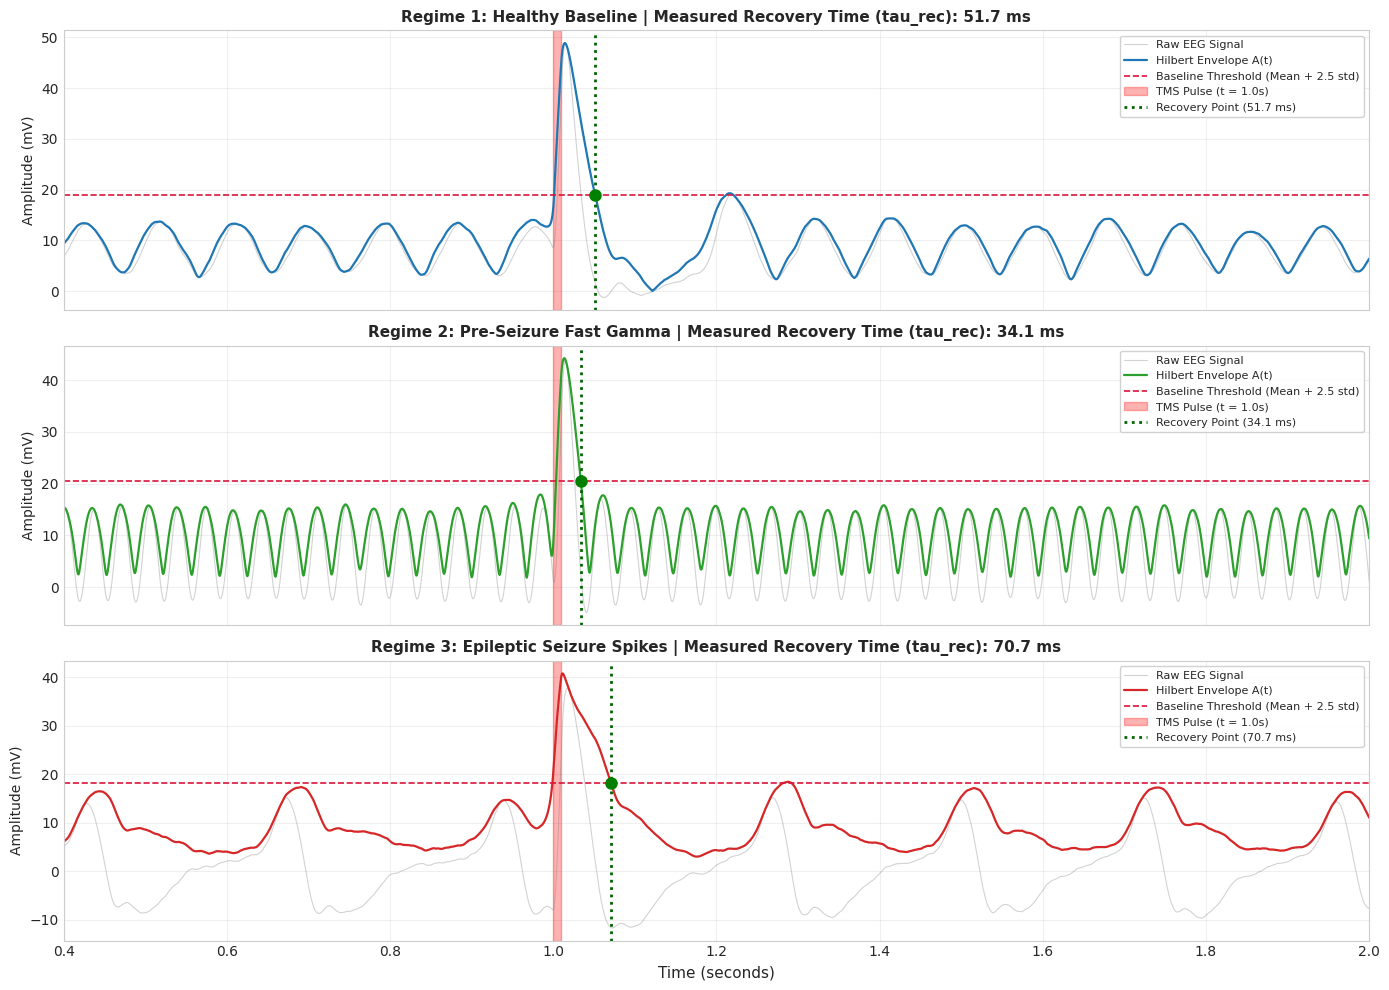

In [6]:
# --- Configuration for Cortical Regimes ---
regimes = {
    "Regime 1: Healthy Baseline": {"B": 15.0, "G": 10.0, "color": "#1f77b4"},
    "Regime 2: Pre-Seizure Fast Gamma": {"B": 1.0, "G": 165.0, "color": "#2ca02c"},
    "Regime 3: Epileptic Seizure Spikes": {"B": 30.0, "G": 0.0, "color": "#d62728"}
}

pulse_start = 1.0  # Pulse injection timestamp at t = 1.0s
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

print("="*70)
print(f"{'QUANTIFICATION RESULTS (Single-Pulse TMS at t = 1.0s)':^70}")
print("="*70)

for idx, (name, config) in enumerate(regimes.items()):
    # Initialize model with exact Wendling parameters for each regime
    sim = WendlingModelQuantification(B=config["B"], G=config["G"], dt=0.0002, T=2.2, random_seed=42)

    t, eeg = sim.simulate(pulse_intensity=2500.0, pulse_start=pulse_start, pulse_duration=0.01)

    # Calculate recovery time using Hilbert envelope
    rec_time, envelope, threshold, t_return = calculate_recovery_time(
        t, eeg, pulse_time=pulse_start, k_sigma=2.5, sustained_ms=50.0, fs=int(1.0/sim.dt)
    )

    if not np.isnan(rec_time):
        rec_str = f"{rec_time * 1000.0:.1f} ms"
    else:
        rec_str = "Sustained Envelope Shift / No Recovery"

    print(f"[{name}] -> Recovery Time (tau_rec): {rec_str}")

    # Render Subplots
    ax = axes[idx]
    ax.plot(t, eeg, color='grey', alpha=0.35, lw=0.8, label='Raw EEG Signal')
    ax.plot(t, envelope, color=config["color"], lw=1.6, label='Hilbert Envelope A(t)')
    ax.axhline(threshold, color='crimson', linestyle='--', lw=1.2, label='Baseline Threshold (Mean + 2.5 std)')
    ax.axvspan(pulse_start, pulse_start + 0.01, color='red', alpha=0.3, label='TMS Pulse (t = 1.0s)')

    if not np.isnan(t_return):
        ax.axvline(t_return, color='darkgreen', linestyle=':', lw=2.0, label=f'Recovery Point ({rec_time*1000.0:.1f} ms)')
        ax.plot(t_return, threshold, 'go', markersize=8)

    ax.set_xlim(0.4, 2.0)
    ax.set_ylabel("Amplitude (mV)", fontsize=10)
    ax.set_title(f"{name} | Measured Recovery Time (tau_rec): {rec_str}", fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)", fontsize=11)
plt.tight_layout()
plt.show()